In [26]:
import numpy as np
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
import evaluate

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("⚠️  No GPU detected. Training will be slow. Consider using Google Colab (Runtime > Change runtime type > T4 GPU).")

Using device: cuda


In [25]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


In [24]:
!jupyter nbconvert --to html --no-input --TagRemovePreprocessor.enabled=True "bert_news_classifier (1).ipynb"

[NbConvertApp] WARNING | pattern 'bert_news_classifier (1).ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]


#Load & Inspect Dataset

In [27]:
raw_dataset = load_dataset("ag_news")
print(raw_dataset)

label_names = raw_dataset["train"].features["label"].names
print("Labels:", label_names)

sample = raw_dataset["train"][0]
print(f"\nSample text: {sample['text']}")
print(f"Label: {label_names[sample['label']]}")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Labels: ['World', 'Sports', 'Business', 'Sci/Tech']

Sample text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Label: Business


In [28]:
N_TRAIN   = 8000
N_TEST    = 1600
MAX_LEN   = 128
EPOCHS    = 5
BATCH     = 16
MODEL_NAME = "bert-base-uncased"

def balanced_sample(dataset, n_total, seed=42):
    n_per_class = n_total // 4
    subsets = []
    for label_id in range(4):
        class_subset = dataset.filter(lambda x: x["label"] == label_id)
        class_subset = class_subset.shuffle(seed=seed).select(range(n_per_class))
        subsets.append(class_subset)
    from datasets import concatenate_datasets
    combined = concatenate_datasets(subsets).shuffle(seed=seed)
    return combined

dataset = balanced_sample(raw_dataset["train"], N_TRAIN)
test_ds = balanced_sample(raw_dataset["test"],  N_TEST)

split    = dataset.train_test_split(test_size=0.2, seed=42)
train_ds = split["train"]
val_ds   = split["test"]

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 6400 | Val: 1600 | Test: 1600


#Tokenize

In [29]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding=False,
        truncation=True,
        max_length=MAX_LEN,
    )

train_tok = train_ds.map(tokenize, batched=True, remove_columns=["text"])
val_tok   = val_ds.map(tokenize,   batched=True, remove_columns=["text"])
test_tok  = test_ds.map(tokenize,  batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Tokenization complete.")
print("Features:", train_tok.features)

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Tokenization complete.
Features: {'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech']), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


#Load Pre-trained BERT

In [30]:
num_labels = len(label_names)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label={i: l for i, l in enumerate(label_names)},
    label2id={l: i for i, l in enumerate(label_names)},
)
print(f"Model loaded: {MODEL_NAME} with {num_labels} output classes")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: bert-base-uncased with 4 output classes


#Define Metrics

In [31]:
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)
    f1  = f1_metric.compute(predictions=preds, references=labels, average="weighted")
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}

#Training Arguments

In [32]:
steps_per_epoch = len(train_ds) // BATCH
warmup_steps    = int(0.1 * steps_per_epoch * EPOCHS)

training_args = TrainingArguments(
    output_dir                  = "./bert-ag-news",
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH,
    per_device_eval_batch_size  = BATCH * 2,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_steps                = warmup_steps,
    label_smoothing_factor      = 0.1,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    logging_steps               = 50,
    fp16                        = torch.cuda.is_available(),
    dataloader_pin_memory       = torch.cuda.is_available(),
    report_to                   = "none",
    push_to_hub                 = False,
)
print(f"Warmup steps: {warmup_steps}")

Warmup steps: 200


#Fine-tune with Trainer

In [34]:
trainer = Trainer(
    model            = model,
    args             = training_args,
    train_dataset    = train_tok,
    eval_dataset     = val_tok,
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
    callbacks        = [EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.544123,0.583692,0.891250,0.891123
2,0.512275,0.557035,0.900000,0.899702
3,0.442912,0.557043,0.908750,0.908838
4,0.397334,0.565204,0.914375,0.914136
5,0.385166,0.570899,0.912500,0.912392


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2000, training_loss=0.49440106105804443, metrics={'train_runtime': 360.2463, 'train_samples_per_second': 88.828, 'train_steps_per_second': 5.552, 'total_flos': 1492540707330816.0, 'train_loss': 0.49440106105804443, 'epoch': 5.0})

#Evaluate on Test Set

In [35]:
results = trainer.evaluate(test_tok)
print("\n Test Set Results:")
for k, v in results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


 Test Set Results:
  eval_loss: 0.5597
  eval_accuracy: 0.9156
  eval_f1: 0.9153
  eval_runtime: 2.9199
  eval_samples_per_second: 547.9720
  eval_steps_per_second: 17.1240
  epoch: 5.0000


#Detailed Classification Report

              precision    recall  f1-score   support

       World       0.92      0.93      0.92       400
      Sports       0.97      0.98      0.98       400
    Business       0.91      0.83      0.87       400
    Sci/Tech       0.86      0.92      0.89       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



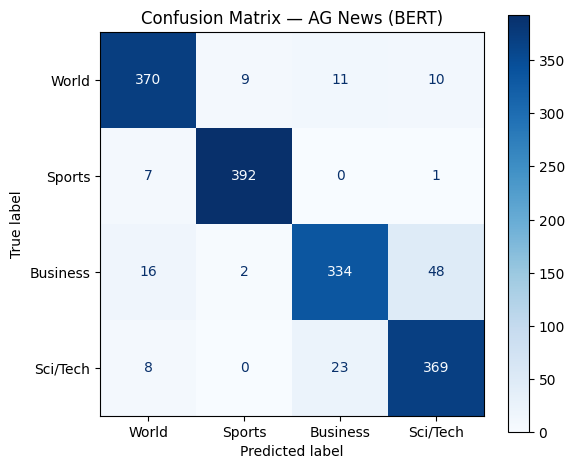

In [36]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions = trainer.predict(test_tok)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=label_names,
    cmap="Blues",
    ax=ax
)
plt.title("Confusion Matrix — AG News (BERT)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()

#Save Model

In [37]:
trainer.save_model("./bert-ag-news-final")
tokenizer.save_pretrained("./bert-ag-news-final")
print("Model saved to ./bert-ag-news-final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./bert-ag-news-final


#Gradio Live Demo


In [38]:
import gradio as gr
from transformers import pipeline
import torch

# Initialize the pipeline
classifier = pipeline(
    "text-classification",
    model="./bert-ag-news-final",
    tokenizer="./bert-ag-news-final",
    device=0 if torch.cuda.is_available() else -1,
    top_k=None,
)

EMOJI = {"World": "🌍", "Sports": "⚽", "Business": "💼", "Sci/Tech": "🔬"}

def predict(text):
    if not text.strip():
        return {}
    results = classifier(text[:512])[0]
    return {
        f"{EMOJI.get(r['label'], r['label'])}": round(r["score"], 4)
        for r in sorted(results, key=lambda x: -x["score"])
    }

examples = [
    ["NASA launches new Mars rover to study the planet's geology and search for signs of ancient life."],
    ["Stock markets surge as Federal Reserve signals potential interest rate cuts next quarter."],
    ["Brazil defeats Argentina 2-1 in the Copa América final after extra time."],
    ["United Nations holds emergency summit to address escalating tensions in the Middle East."],
]

demo = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Paste a news headline or article snippet here...",
        label="News Text",
    ),
    outputs=gr.Label(num_top_classes=4, label="Category Probabilities"),
    title="📰 News Topic Classifier (BERT)",
    description="Classifies news into: World 🌍 · Sports ⚽ · Business 💼 · Sci/Tech 🔬",
    examples=examples,
    theme=gr.themes.Soft(),
)

demo.launch(
    share=True,
    debug=False,
    show_error=True
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b68aca77520d2dec7a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
